In [1]:
# ==============================
# Retail Data Analytics Project
# Author: Ajay Nethi
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")


Libraries Loaded Successfully


In [5]:
# Load dataset
df = pd.read_csv(r"C:\Users\AJAY\Downloads\Retail-Data-Analytics-Project-Python-SQL-Integration-main\Retail-Data-Analytics-Project-Python-SQL-Integration-main\orders.csv")

print("Dataset Loaded Successfully")
df.head()


Dataset Loaded Successfully


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5


In [6]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
df.describe()


Rows and Columns: (9994, 16)

Data Types:
Order Id             int64
Order Date          object
Ship Mode           object
Segment             object
Country             object
City                object
State               object
Postal Code          int64
Region              object
Category            object
Sub Category        object
Product Id          object
cost price           int64
List Price           int64
Quantity             int64
Discount Percent     int64
dtype: object

Summary Statistics:


,Order Id,Postal Code,cost price,List Price,Quantity,Discount Percent
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,201.189714,229.756854,3.789574,3.484090
std,2885.163629,32063.693350,537.743203,623.245839,2.225110,1.114211
min,1.000000,1040.000000,0.000000,0.000000,1.000000,2.000000
25%,2499.250000,23223.000000,20.000000,20.000000,2.000000,2.000000
50%,4997.500000,56430.500000,50.000000,50.000000,3.000000,3.000000
75%,7495.750000,90008.000000,180.000000,210.000000,5.000000,4.000000
max,9994.000000,99301.000000,18110.000000,22640.000000,14.000000,5.000000


In [7]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create Month column
df["Month"] = df["Order Date"].dt.to_period("M")

print("Data Cleaning Completed")


Missing Values:
Order Id            0
Order Date          0
Ship Mode           1
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Category            0
Sub Category        0
Product Id          0
cost price          0
List Price          0
Quantity            0
Discount Percent    0
dtype: int64
Data Cleaning Completed


In [10]:
print(df.columns)


Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'Month'],
      dtype='object')


In [11]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Order Id', 'Order Date', 'Ship Mode', 'Segment', 'Country', 'City',
       'State', 'Postal Code', 'Region', 'Category', 'Sub Category',
       'Product Id', 'cost price', 'List Price', 'Quantity',
       'Discount Percent', 'Month'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

print(df.columns)


Index(['order_id', 'order_date', 'ship_mode', 'segment', 'country', 'city',
       'state', 'postal_code', 'region', 'category', 'sub_category',
       'product_id', 'cost_price', 'list_price', 'quantity',
       'discount_percent', 'month'],
      dtype='object')


In [14]:
# Create Sales column
df["sales"] = df["list_price"] * df["quantity"]

# Create Profit column
df["profit"] = (df["list_price"] - df["cost_price"]) * df["quantity"]

df.head()


,order_id,order_date,ship_mode,segment,country,city,state,postal_code,region,category,sub_category,product_id,cost_price,list_price,quantity,discount_percent,month,sales,profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,2023-03,520,40
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,2023-08,2190,390
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,2023-01,20,0
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,2022-06,4800,900
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,2022-07,40,0


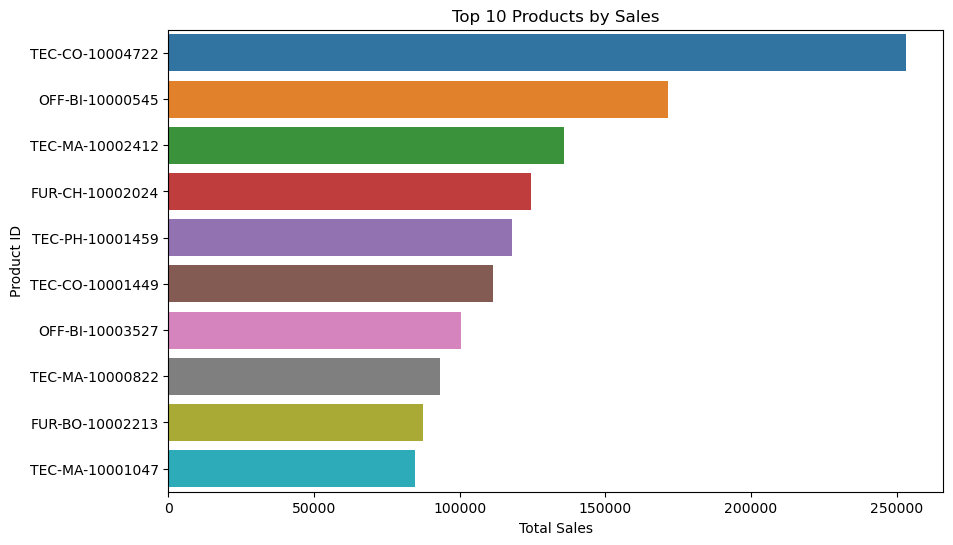

In [15]:
top_products = df.groupby("product_id")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product ID")
plt.show()


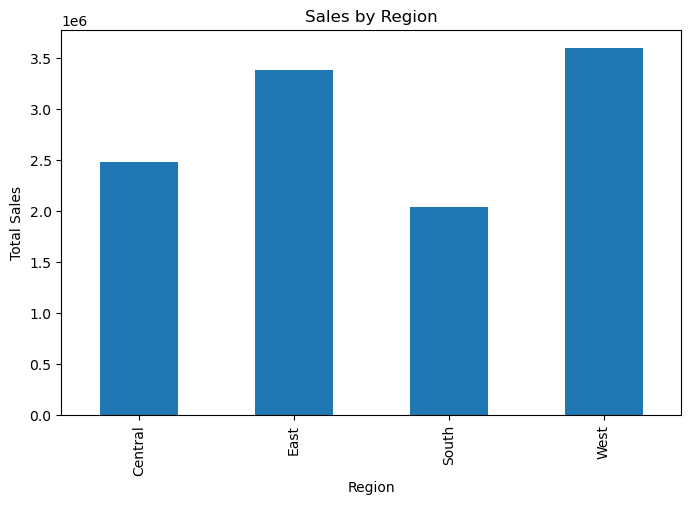

In [16]:
region_sales = df.groupby("region")["sales"].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


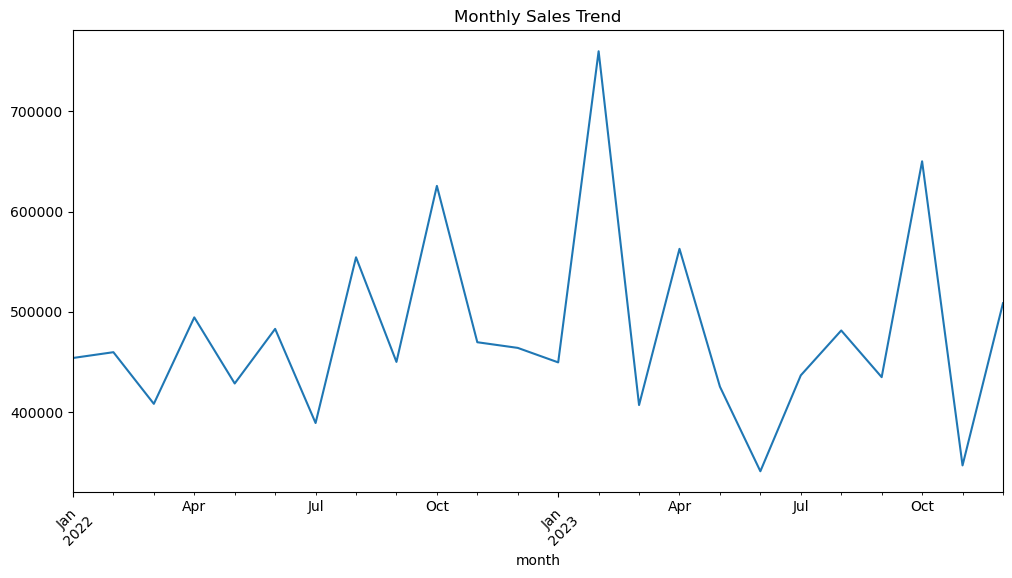

In [17]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M")

monthly_sales = df.groupby("month")["sales"].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()


In [19]:
# Convert datetime to string
df["order_date"] = df["order_date"].astype(str)

# Convert month to string
df["month"] = df["month"].astype(str)


In [20]:
import sqlite3

# Create database connection
conn = sqlite3.connect("retail.db")

# Load dataframe into database
df.to_sql("orders", conn, if_exists="replace", index=False)

print("Data successfully loaded into SQLite database")


Data successfully loaded into SQLite database


In [21]:
query = """
SELECT region, SUM(sales) AS total_sales
FROM orders
GROUP BY region
ORDER BY total_sales DESC;
"""

result = pd.read_sql(query, conn)
result


,region,total_sales
0,West,3594450
1,East,3378470
2,Central,2475030
3,South,2037220


In [23]:
query = """
SELECT product_id, SUM(profit) AS total_profit
FROM orders
GROUP BY product_id
ORDER BY total_profit DESC
LIMIT 5;
"""

pd.read_sql(query, conn)


,product_id,total_profit
0,TEC-CO-10004722,33160
1,TEC-MA-10002412,27180
2,OFF-BI-10000545,25600
3,TEC-CO-10001449,20040
4,FUR-CH-10002024,18310


In [24]:
query = """
SELECT category, SUM(sales) AS total_sales
FROM orders
GROUP BY category
ORDER BY total_sales DESC;
"""

pd.read_sql(query, conn)


,category,total_sales
0,Technology,4080330
1,Furniture,3857390
2,Office Supplies,3547450
